# IHM. Protocole HTTP

Cette activité a pour but de tester le protocole HTTP et notamment les méthodes GET et POST.

<u>Source</u> : David Roche, site https://pixees.fr/

Comme déjà évoqué dans la partie consacrée au modèle client-serveur, un serveur web (aussi appelé serveur HTTP) permet de répondre à une requête HTTP effectuée par un client (très souvent un navigateur web). On va travailler ici avec le serveur web qui est déjà installé sur chaque ordinateur. 

Il s'agit d'une configuration un peu particulière puisque <b>le client et le serveur vont se trouver sur la même machine</b>. Cette configuration est classique lorsque l'on désire effectuer de simples tests. Il aura 2 logiciels sur le même ordinateur : 
<u>le client (navigateur web)</u> et <u>le serveur (serveur web)</u>, ces 2 logiciels vont communiquer en utilisant le protocole HTTP. 

On va travailler avec le framework Python Flask. Ce framework va nous permettre de générer des pages web côté serveur, il possède son propre serveur web. 

## <u>Activité 1</u> : une page statique basique

<u>Rappel</u> : une page statique est une page web qui ne change jamais quelque soit la requête d'un navigateur (par exemple, une page https://fr.wikipedia.org/wiki/Wikip%C3%A9dia:Accueil_principal )



1/ <b>Exécuter</b> le code suivant :

In [ ]:
from flask import Flask

app = Flask(__name__)

@app.route('/')
def index():
    return "<p> Tout fonctionne bien </p>"

if __name__ == "__main__":
    app.run()


Normalement, ceci doit s'afficher :
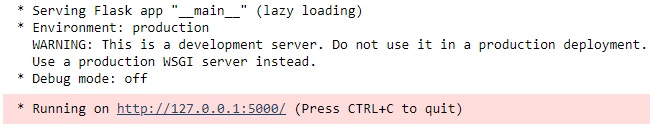


Il suffit de <u>cliquer</u> sur le lien et le navigateur s'ouvre en affichant <i>"Tout fonctionne bien"</i>

<u>Remarque :</u> : Il faudra peut être interrompre le noyau (le <i>carré noir</i> à droite de <i>Exécuter</i>) pour stopper le programme, la combinaison CTRL + C ne fonctionnant pas tout le temps.

<b><u>Quelques explications</u></b> : 

A propos du "localhost:5000" : comme déjà dit, notre serveur et notre client se trouvent sur la même machine, avec le "localhost", on indique au navigateur que le serveur web se trouve sur le même ordinateur que lui (on parle de machine locale). Dans un cas normal, la barre d'adresse devrait être renseignée avec l'adresse du serveur web. Le "5000" indique le port, c'est à dire le canal utilisé pour communiquer.

2/ La page est située à la <b>racine</b> du projet (d'où le `@app.route('/')`). On peut tout à fait charger une autre page en indiquant son <b>chemin relatif</b>.

<b>Exécuter</b> le programme suivant et afficher le contenu de chaque page en entrant les bonnes URL dans le navigateur.

### <u>Appel au professeur</u> (si besoin)

In [ ]:
from flask import Flask

app = Flask(__name__)

@app.route('/')
def index():
    return "<p>Tout fonctionne bien </p>"

######## Ajout d'une nouvelle page ###########
@app.route('/about')
def about():
    return "<p>Voici une autre page</p>"

if __name__ == "__main__":
    app.run()

Une fois chaque page affichée, il doit y avoir ce message qui s'affiche :
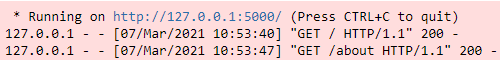

<b><u>Quelques explications</u></b>

<ul>
    <li> <b>127.0.0.1</b> est l'adresse IP (dite locale ici) où se situe le serveur. </li>
    <li> <b>GET</b> est la méthode employée pour la requête. L'URL est bien visible.</li>
    <li> <b>HTTP/1.1</b> indique que c'est le protocole HTTP version 1.1 qui est utilisé.</li>
    <li> Le code <b>200</b> indique que tout s'est bien passé. </li>
</ul>

## <u>Activité 2</u> : import de fichiers html

Il n'est pas très pratique d'écrire du code html dans un programme en Python. Flask propose une solution pour séparer <i>"partie en Python"</i> et <i>"partie Web"</i>.

1/ Sur Notepad++, <b>écrire</b> le code html minimal suivant et le <b>sauvegarder</b> sous `index.html`.
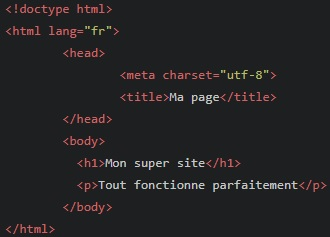

2/ <b>Créer</b> un répertoire `templates` dans Jupyter et y <b>monter</b> le fichier `index.html`.
    

3/ <b>Exécuter</b> alors le programme suivant :

In [ ]:
from flask import Flask, render_template

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html')

###### NE PAS MODIFIER ######
app.run()
#############################

Si tout se passe bien, ceci doit s'afficher :
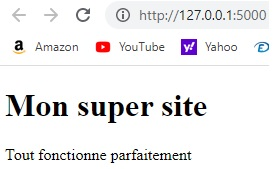

### <u>Appel au professeur</u> (si besoin)



## <u>Activité 3</u> : du dynamisme avec Python 

Le site va désormais afficher l'heure réelle. Pour cela, on va modifier ce fichier mais également le fichier `index.html` pour pour passer les variables en argument.

1/ <b>Modifier</b> le programme en suivant les instructions ici :
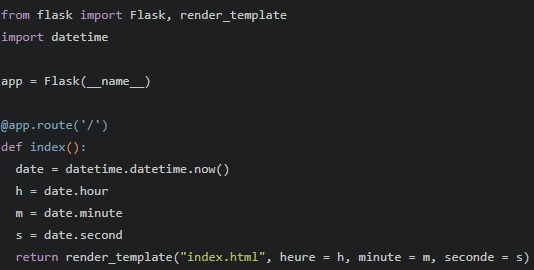

<b><u>Important</u></b> : <b>ne pas exécuter le programme pour l'instant, le fichier `index.html` doit aussi être modifié.</b>

In [ ]:
from flask import Flask, render_template
import datetime

app = Flask(__name__)

@app.route('/')
def index():
    date = datetime.datetime.now()
    h = date.hour
    m = date.minute
    s = date.second
    return render_template('index.html',heure = h, minute = m, seconde = s)

###### NE PAS MODIFIER NI SUPPRIMER ######
app.run()
##########################################

2/ <b>Modifier</b> le fichier `index.html` comme ci-dessus.
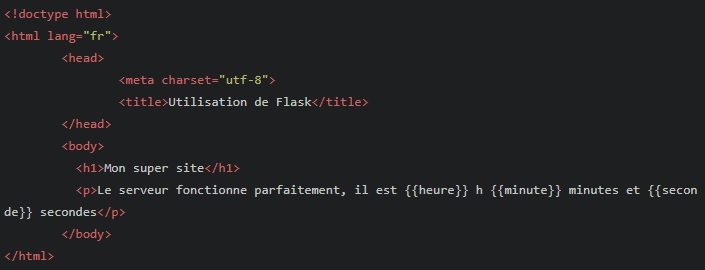

<b><u>Remarque</u></b> : dans Jupyter, il faut editer le fichier en question et ne pas cliquer dessus directement !
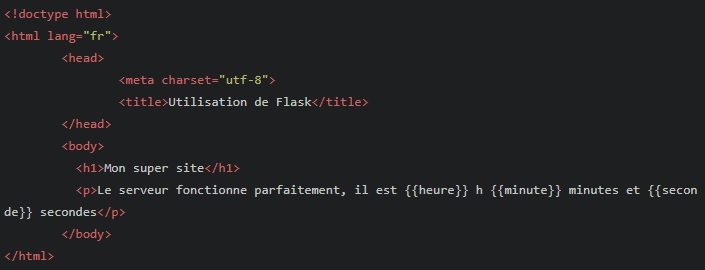

3/ <b>Exécuter</b> le script à la question 1, normalement, une page web comme celle-ci doit s'afficher (avec l'heure actuelle).
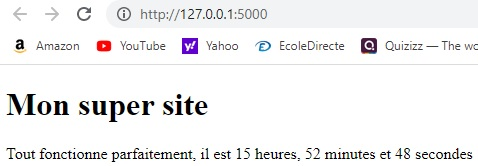

### <u>Appel au professeur</u> si besoin.

<b><u>Quelques explications</u></b>

On a bien une page dynamique, puisqu'à chaque fois que l'on actualise la page dans votre navigateur, 
l'heure courante s'affiche : <b>à chaque fois que l'on actualise la page, on effectue une nouvelle requête 
et en réponse à cette requête, le serveur envoie une nouvelle page HTML.</b>

Attention, il est bien important de comprendre que la page HTML envoyée par le serveur au client ne contient plus les paramètres {{heure}}, {{minute}} et {{seconde}}. 

## <u>Activité 4</u> : Envoi de formulaire

### <u>Partie I</u> : la méthode POST

1/ <b>Modifier</b> le fichier `index.html` comme ci-dessous

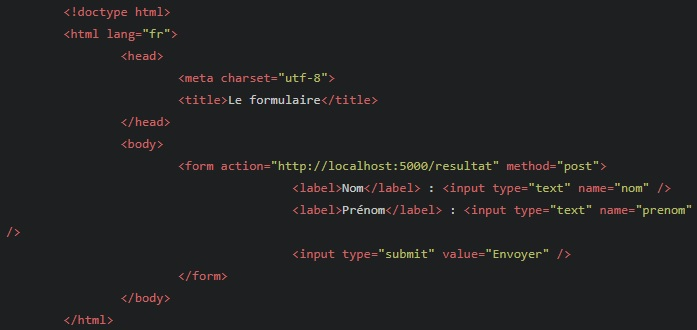

2/<b>Créer</b> à l'aide de Notepad un fichier nommé `resultat.html` qui sera à <b>monter</b> dans le répertoire `templates`de Jupyter. Le voici en détail :
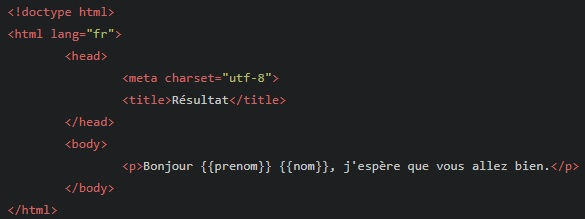

<b><u>Conseil</u></b> : on peut vérifier que le code html fonctionne correctement dans le navigateur avant de le monter dans Jupyter ! Il n'y aura bien sûr pas d'envoi de formulaire.


3/ <b>Exécuter</b> alors le script suivant :

In [ ]:
from flask import Flask, render_template, request

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/resultat',methods = ['POST'])
def resultat():
    result = request.form
    n = result['nom']
    p = result['prenom']
    return render_template("resultat.html", nom=n, prenom=p)

app.run()

On doit obtenir ceci dans le navigateur (avec vos noms / prénoms bien sûr) :
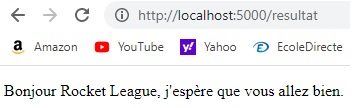

<b><u>Important</u></b> : on constate qu'il n'y a <b>aucune trace des données</b> indiquées dans le formulaire dans l'URL. Ceci est normal car dans ce cas, les informations sont passées directement au serveur.

Et ceci dans la console de Jupyter :
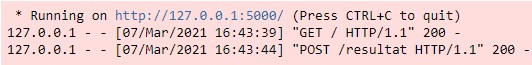

<b><u>Quelques explications</u></b>
<ul>
    <li> La première ligne indique que l'on a utilisé la méthode <b>GET</b> pour accéder à l'adresse souhaitée. </li>
    <li> La seconde ligne indique bien que l'on a utilisé la méthode <b>POST</b> pour transmettre les informations du formulaire au serveur. </li>
</ul>

### <u>Appel au professeur</u> si besoin

### <u>Partie II</u> : la méthode GET

1/ Dans le fichier `index.html`, <b>changer</b> la méthode "post" en "get". Le fichier `resultat.html` reste inchangé.
<b>Exécuter</b> alors le script suivant :

In [ ]:
from flask import Flask, render_template, request

app = Flask(__name__)

@app.route('/')
def index():
    return render_template('index.html')

@app.route('/resultat',methods = ['GET']) # Méthode "get"
def resultat():
    result=request.args  # Récupération des arguments de l'url
    n = result['nom']
    p = result['prenom']
    return render_template("resultat.html", nom=n, prenom=p)

app.run()

On doit obtenir ceci (avec vos données) :
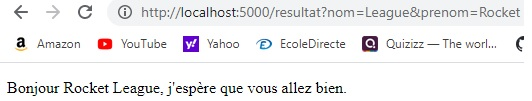

Et dans Jupyter :
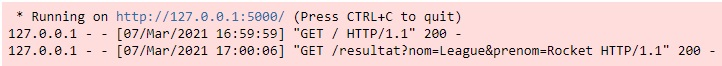

### <u>Appeler le professeur</u> si besoin

<b><u>Quelques explications</u></b>

On constate très clairement que les données sont bien visibles dans l'adresse URL et que l'on a utilisé à chaque fois la méthode <b>GET</b>.

<b><u>Remarque</u></b> : Il est important de bien comprendre que la méthode "POST" n'offre pas non plus une sécurité absolue puisque toute personne ayant un bagage technique minimum sera capable de lire les données transmises à l'aide de la méthode "POST" en analysant la requête HTTP, même si ces données ne sont pas directement visibles dans l'URL. 

Seule l'utilisation du <b>protocole sécurisé HTTPS</b> garantit un transfert sécurisé des données entre le client et le serveur (les données sont chiffrées et donc illisibles pour une personne ne possédant pas la clé de déchiffrement).


